# Clasificación de Vinos: Construcción, Guardado y Uso del Modelo

Este notebook une las **dos partes** del ejercicio en un solo flujo:

- **Parte A — Construcción del modelo**: se entrena un `Pipeline` (`StandardScaler` + `SVC` lineal) con el dataset **Wine** de scikit-learn, usando 4 características, y se guarda como `modelo_wine.pkl`.
- **Parte B — Uso del modelo**: se recupera `modelo_wine.pkl` y se utiliza para predecir vinos nuevos, sin volver a entrenar nada.

Las etiquetas `Cabernet`, `Merlot` y `Pinot Noir` son **nombres didácticos** asignados a las clases 0, 1 y 2 del dataset original; no corresponden a variedades reales identificadas por scikit-learn.

---
# Parte A — Construcción del modelo de clasificación de vinos

## Paso 1 — Importar las librerías

In [20]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

## Paso 2 — Cargar el dataset

Cargamos el dataset **Wine** de scikit-learn, lo convertimos en DataFrame y agregamos la variable objetivo.

In [21]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Paso 3 — Asignar nombres a las clases

Mapeamos las clases originales (0, 1, 2) a las etiquetas didácticas `Cabernet`, `Merlot` y `Pinot Noir`, y las guardamos en una nueva columna `tipo_vino`.

> Estas etiquetas se usan solo con fines didácticos y no corresponden a variedades identificadas por el dataset original.

In [22]:
nombres_clase = {0: "Cabernet", 1: "Merlot", 2: "Pinot Noir"}
df["tipo_vino"] = df["target"].map(nombres_clase)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,tipo_vino
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Cabernet
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Cabernet
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Cabernet
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Cabernet
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Cabernet


## Paso 4 — Exploración inicial de los datos

In [23]:
print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

Dimensiones del dataset: (178, 15)

Tipos de datos:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
tipo_vino                        object
dtype: object


In [24]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
tipo_vino                       0
dtype: int64


In [25]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [26]:
print("Cantidad de registros por tipo de vino:")
print(df["tipo_vino"].value_counts())

Cantidad de registros por tipo de vino:
tipo_vino
Merlot        71
Cabernet      59
Pinot Noir    48
Name: count, dtype: int64


**Respuestas (Paso 4):**

- **¿Existen valores faltantes?** No, el dataset `Wine` de scikit-learn no tiene valores nulos en ninguna columna.
- **¿Las tres clases contienen la misma cantidad de registros?** No están perfectamente balanceadas: hay 59 `Cabernet`, 71 `Merlot` y 48 `Pinot Noir`. La diferencia no es extrema, pero conviene tenerla en cuenta al evaluar el modelo (por eso se usa `stratify` en el split).
- **¿Se observa alguna diferencia importante entre las escalas de las variables?** Sí. Por ejemplo `proline` toma valores en cientos/miles, mientras que `malic_acid` o `alcohol` están en un rango mucho más pequeño (unidades). Por eso es necesario escalar las variables antes de entrenar el SVM.

## Paso 5 — Definir las variables del modelo

Usamos únicamente 4 características: `alcohol`, `malic_acid`, `color_intensity` y `proline`.

In [27]:
caracteristicas = ["alcohol", "malic_acid", "color_intensity", "proline"]

X = df[caracteristicas]
y = df["tipo_vino"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (178, 4)
Dimensiones de y: (178,)


## Paso 6 — Crear los conjuntos de entrenamiento y prueba

80 % entrenamiento / 20 % prueba, con `random_state=42` y división **estratificada** según `y`.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

X_train: (142, 4) | X_test: (36, 4)
y_train: (142,) | y_test: (36,)


**Respuestas (Paso 6):**

- **¿Por qué no se utiliza el 100 % de los datos para entrenar?** Porque necesitamos datos que el modelo nunca haya visto para evaluar honestamente qué tan bien generaliza. Si se evalúa con los mismos datos de entrenamiento, el desempeño reportado sería artificialmente alto.
- **¿Qué función cumple la estratificación?** Mantiene la misma proporción de cada clase (`Cabernet`, `Merlot`, `Pinot Noir`) tanto en el conjunto de entrenamiento como en el de prueba, evitando que por azar algún grupo quede sub- o sobre-representado en alguno de los dos conjuntos.

## Pasos 7 y 8 — Construir y entrenar el Pipeline

El `Pipeline` encadena `StandardScaler` (escalamiento) con `SVC(kernel="linear")` (clasificador).

In [29]:
modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", random_state=42))
])

modelo.fit(X_train, y_train)

print("Clases aprendidas por el modelo:", modelo.classes_)

Clases aprendidas por el modelo: ['Cabernet' 'Merlot' 'Pinot Noir']


**¿Por qué conviene incluir el escalamiento y el modelo dentro del mismo Pipeline?**
Porque así el escalado se ajusta (`fit`) únicamente con los datos de entrenamiento y luego se aplica automáticamente, en el mismo orden, a cualquier dato nuevo antes de clasificarlo. Esto evita fugas de información (*data leakage*) y errores manuales, ya que basta con llamar `.predict()` una sola vez sobre el Pipeline completo.

## Paso 9 — Realizar las predicciones

Generamos las predicciones sobre el conjunto de prueba y las comparamos con los valores reales.

In [30]:
y_pred = modelo.predict(X_test)

comparacion = pd.DataFrame({"Real": y_test.values, "Predicho": y_pred})
comparacion.head(10)

,Real,Predicho
0,Cabernet,Cabernet
1,Pinot Noir,Merlot
2,Cabernet,Cabernet
3,Merlot,Pinot Noir
4,Merlot,Merlot
5,Cabernet,Cabernet
6,Cabernet,Cabernet
7,Merlot,Merlot
8,Merlot,Merlot
9,Pinot Noir,Pinot Noir


## Paso 10 — Evaluar el modelo

In [31]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred))

Accuracy : 0.9167
Precision: 0.9185
Recall   : 0.9095
F1-score : 0.9129

              precision    recall  f1-score   support

    Cabernet       1.00      1.00      1.00        12
      Merlot       0.87      0.93      0.90        14
  Pinot Noir       0.89      0.80      0.84        10

    accuracy                           0.92        36
   macro avg       0.92      0.91      0.91        36
weighted avg       0.92      0.92      0.92        36



## Paso 11 — Matriz de confusión

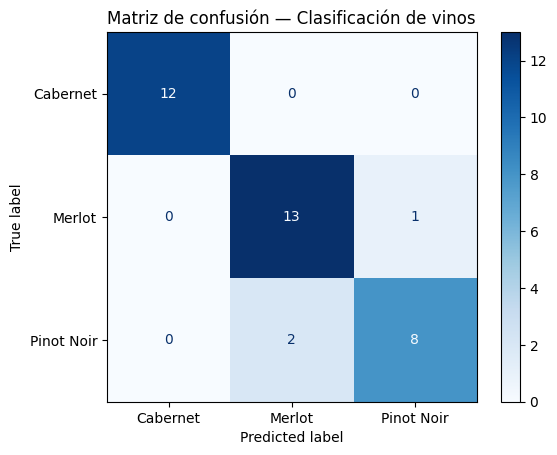

In [32]:
cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión — Clasificación de vinos")
plt.show()

**Análisis (Paso 11):** revisa la diagonal de la matriz (predicciones correctas) frente a los valores fuera de ella (errores). Anota aquí qué clase concentra más confusión entre sí, en tus propios resultados al ejecutar el notebook.

## Paso 12 — Probar un nuevo vino

Probamos el modelo recién entrenado con una observación nueva, antes de guardarlo.

In [33]:
vino_nuevo_A = pd.DataFrame([{
    "alcohol": 13.5,
    "malic_acid": 1.8,
    "color_intensity": 5.2,
    "proline": 1000
}])

prediccion_A = modelo.predict(vino_nuevo_A)
print(f"Tipo de vino predicho (antes de guardar el modelo): {prediccion_A[0]}")

Tipo de vino predicho (antes de guardar el modelo): Cabernet


---
# Parte B — Guardar y usar el modelo entrenado

## Paso 13 — Guardar el modelo

Usamos `joblib` para almacenar el Pipeline completo (escalador + SVM) ya entrenado.

In [34]:
import os

joblib.dump(modelo, "modelo.pkl")

print("¿Se generó el archivo?:", os.path.exists("modelo.pkl"))

¿Se generó el archivo?: True


## Paso 14 — Recuperar el modelo

Cargamos `modelo_wine.pkl` como si fuera una sesión distinta, sin volver a entrenar nada.

In [35]:
modelo_recuperado = joblib.load("modelo_wine.pkl")
print("Modelo recuperado correctamente.")
print(modelo_recuperado)

Modelo recuperado correctamente.
Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(kernel='linear', random_state=42))])


### Comparar la predicción antes y después de guardar

Usamos el **mismo** vino del Paso 12 para confirmar que el modelo recuperado predice exactamente igual que el original.

In [36]:
prediccion_B = modelo_recuperado.predict(vino_nuevo_A)

print(f"Predicción con el modelo original  (Paso 12): {prediccion_A[0]}")
print(f"Predicción con el modelo recuperado (Paso 14): {prediccion_B[0]}")
print("¿Coinciden?:", prediccion_A[0] == prediccion_B[0])

Predicción con el modelo original  (Paso 12): Cabernet
Predicción con el modelo recuperado (Paso 14): Cabernet
¿Coinciden?: True


## Uso del modelo con más observaciones

Igual que en la práctica de uso del modelo: creamos varios vinos y obtenemos todas las predicciones de una sola vez, agregando el resultado en una columna `tipo_vino`.

In [37]:
vinos = pd.DataFrame([
    {"alcohol": 14.23, "malic_acid": 1.71, "color_intensity": 5.64, "proline": 1065},
    {"alcohol": 12.37, "malic_acid": 1.17, "color_intensity": 1.95, "proline": 520},
    {"alcohol": 13.40, "malic_acid": 3.91, "color_intensity": 7.30, "proline": 750},
])

resultado = vinos.copy()
resultado["tipo_vino"] = modelo_recuperado.predict(vinos)

resultado

,alcohol,malic_acid,color_intensity,proline,tipo_vino
0,14.23,1.71,5.64,1065,Cabernet
1,12.37,1.17,1.95,520,Merlot
2,13.40,3.91,7.30,750,Pinot Noir


## Reflexión final

**Diferencia entre entrenar un modelo y utilizar un modelo previamente entrenado:**

- **Entrenar** (Parte A) es un proceso que requiere datos históricos, ajustar los parámetros del escalador y del SVM, y evaluar su desempeño. Es un paso que se hace una sola vez (o cada vez que se quiere mejorar el modelo) y puede ser costoso en tiempo y cómputo.
- **Utilizar un modelo ya entrenado** (Parte B) consiste simplemente en cargar el archivo `.pkl` con `joblib.load()` y llamar `.predict()` con datos nuevos. Es rápido, no requiere los datos originales de entrenamiento y se puede repetir en cualquier notebook, aplicación o servidor que tenga acceso al archivo.

**Flujo completo de la práctica:**

`Datos (Wine, scikit-learn) → preparación (features + tipo_vino) → Pipeline (StandardScaler + SVC) → entrenamiento (fit) → evaluación (accuracy, precision, recall, F1, matriz de confusión) → Joblib (dump) → modelo_wine.pkl → Joblib (load) → predicciones sobre datos nuevos`